Analisis de Cluster 

Este analisis se realiza a una base de datos de uso de tarjetas de credito

La informacion es tomada de 
https://www.kaggle.com/datasets/arjunbhasin2013/ccdata?resource=download

El diccionario de la data es:

CUST_ID : Identificación del titular de la tarjeta de crédito (categórica)
BALANCE : Monto del saldo que le queda en su cuenta para realizar compras 
BALANCE_FREQUENCY : Con qué frecuencia se actualiza el saldo, puntuación entre 0 y 1 (1 = se actualiza con frecuencia, 0 = no se actualiza con frecuencia)
PURCHASES : Monto de las compras realizadas desde la cuenta
ONEOFF_PURCHASES : Monto máximo de compra realizada en una sola vez
INSTALLMENTS_PURCHASES : Monto de la compra realizada en cuotas
CASH_ADVANCE : Efectivo por adelantado entregado por el usuario
PURCHASES_FREQUENCY : Con qué frecuencia se realizan las compras, puntuación entre 0 y 1 (1 = compradas con frecuencia, 0 = no compradas con frecuencia)
ONEOFFPURCHASESFREQUENCY : Con qué frecuencia se realizan las compras en una sola vez (1 = compradas con frecuencia, 0 = no compradas con frecuencia)
PURCHASESINSTALLMENTSFREQUENCY : Con qué frecuencia se realizan las compras en cuotas hecho (1 = hecho frecuentemente, 0 = no hecho frecuentemente)
CASHADVANCEFREQUENCY : Con qué frecuencia se paga el efectivo por adelantado
CASHADVANCETRX : Número de transacciones realizadas con "Efectivo por adelantado"
PURCHASES_TRX : Número de transacciones de compra realizadas
CREDIT_LIMIT : Límite de tarjeta de crédito para el usuario
PAYMENTS : Monto del pago realizado por el usuario
MINIMUM_PAYMENTS : Monto mínimo de pagos realizados por el usuario
PRCFULLPAYMENT : Porcentaje del pago total pagado por el usuario
TENURE : Duración del servicio de tarjeta de crédito para el usuario


In [1]:
# Cargue de librerias

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

In [3]:
# Lectura de archivo
df = pd.read_csv('CreditCard.csv')
print(df.shape)

#Eliminacion de columnas
df= df.drop(['BALANCE_FREQUENCY','PURCHASES_FREQUENCY','PURCHASES_INSTALLMENTS_FREQUENCY','ONEOFF_PURCHASES_FREQUENCY'],axis=1)
df.dropna()

# Estadisticas iniciales
print(df.shape)
print(df.describe())
print(df.info())

(8950, 18)
(8950, 14)
            BALANCE     PURCHASES  ONEOFF_PURCHASES  INSTALLMENTS_PURCHASES  \
count   8950.000000   8950.000000       8950.000000             8950.000000   
mean    1564.474828   1003.204834        592.437371              411.067645   
std     2081.531879   2136.634782       1659.887917              904.338115   
min        0.000000      0.000000          0.000000                0.000000   
25%      128.281915     39.635000          0.000000                0.000000   
50%      873.385231    361.280000         38.000000               89.000000   
75%     2054.140036   1110.130000        577.405000              468.637500   
max    19043.138560  49039.570000      40761.250000            22500.000000   

       CASH_ADVANCE  CASH_ADVANCE_FREQUENCY  CASH_ADVANCE_TRX  PURCHASES_TRX  \
count   8950.000000             8950.000000       8950.000000    8950.000000   
mean     978.871112                0.135144          3.248827      14.709832   
std     2097.163877       

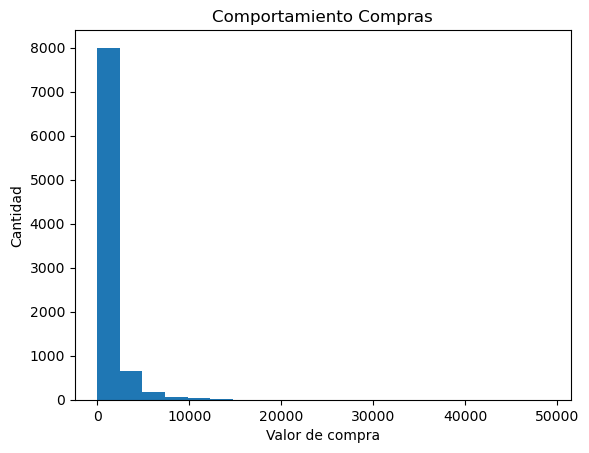

In [4]:
#Grafica del comportamiento de las compras
plt.hist(df['PURCHASES'],bins=20)
plt.title('Comportamiento Compras')
plt.xlabel('Valor de compra')
plt.ylabel('Cantidad')
plt.show()

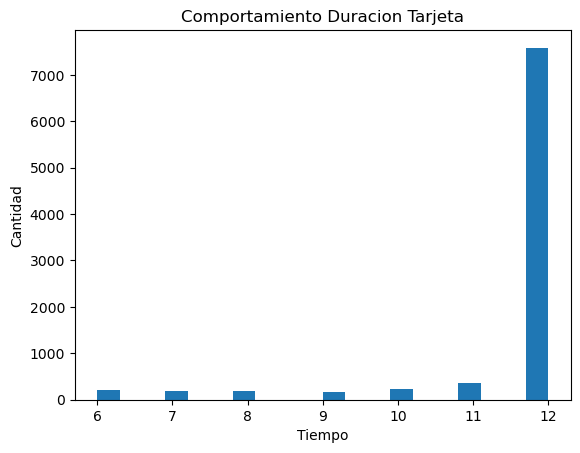

In [5]:
#Grafica del comportamiento de la duracion
plt.hist(df['TENURE'],bins=20)
plt.title('Comportamiento Duracion Tarjeta')
plt.xlabel('Tiempo')
plt.ylabel('Cantidad')
plt.show()

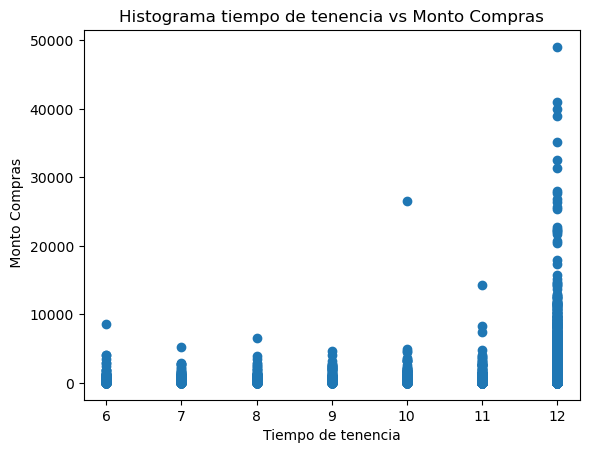

In [6]:
#Grafica de Histograma entre Compras y Duracion 
plt.scatter(df['TENURE'],df['PURCHASES'])
plt.title('Histograma tiempo de tenencia vs Monto Compras')
plt.xlabel('Tiempo de tenencia')
plt.ylabel(' Monto Compras')
plt.show()

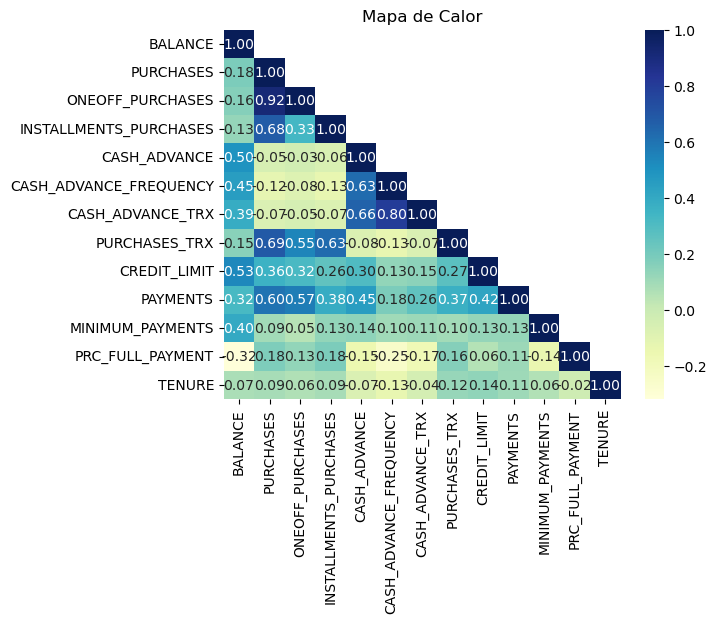

In [7]:
#Correlacion
correlacion = df.drop(['CUST_ID'],axis=1).corr()

#Mapa de Calor
mask=np.triu(correlacion,k=1)
sns.heatmap(correlacion,cmap='YlGnBu',annot=True,fmt=".2f",mask=mask)
plt.title('Mapa de Calor')
plt.show()


count    8950.000000
mean       14.709832
std        24.857649
min         0.000000
25%         1.000000
50%         7.000000
75%        17.000000
max       358.000000
Name: PURCHASES_TRX, dtype: float64


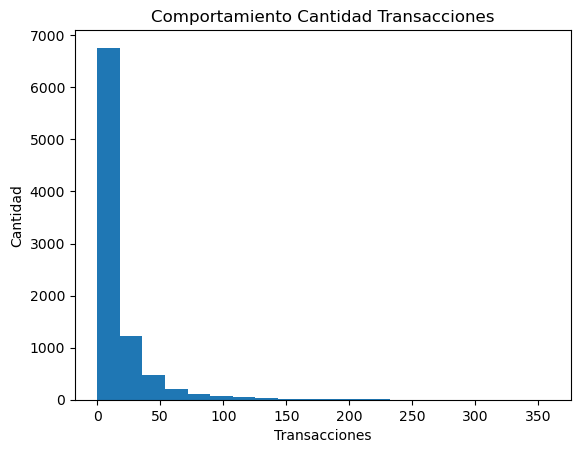

In [9]:
#Estadisticas de la cantidad de transacciones
print(df['PURCHASES_TRX'].describe())

#Grafica del comportamiento de las compras
plt.hist(df['PURCHASES_TRX'],bins=20)
plt.title('Comportamiento Cantidad Transacciones')
plt.xlabel('Transacciones')
plt.ylabel('Cantidad')
plt.show()



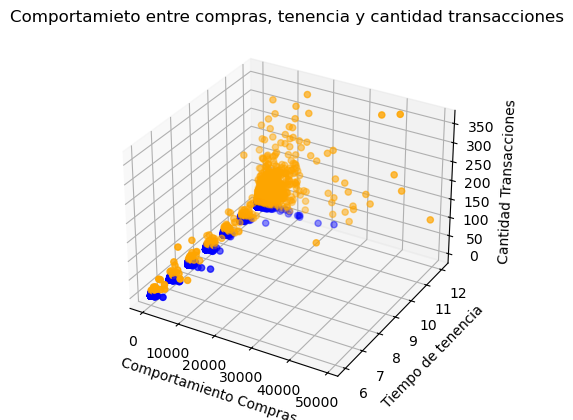

In [ ]:
#Grafica de Histograma entre Compras, Duracion y Cantidad Transacciones
# Grafica 3D 
x = df['PURCHASES']
y = df['TENURE']
z = df['PURCHASES_TRX']

# Asignacionde Color a las transacciones mas altas
colors = np.where(z > 14.7, "orange", "blue")

fig = plt.figure()
ax = fig.add_subplot(projection = '3d')
ax.scatter(x, y, z, c = colors)
ax.set_xlabel('Comportamiento Compras')
ax.set_ylabel('Tiempo de tenencia')
ax.set_zlabel('Cantidad Transacciones')
plt.title('Comportamieto entre compras, tenencia y cantidad transacciones')
plt.show()

      PURCHASES  PURCHASES_TRX
0         95.40              2
1          0.00              0
2        773.17             12
3       1499.00              1
4         16.00              1
...         ...            ...
8945     291.12              6
8946     300.00              6
8947     144.40              5
8948       0.00              0
8949    1093.25             23

[8950 rows x 2 columns]


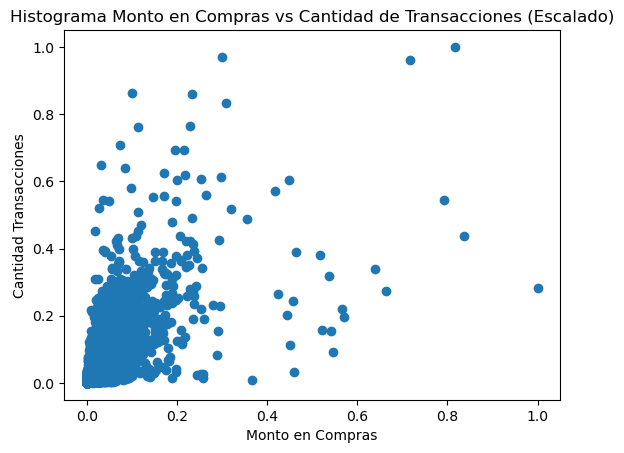

In [11]:
# Dataframe con las variables a analizar 
dfPP=df[['PURCHASES','PURCHASES_TRX']]
print(dfPP)

#Escalado de los datos
df_escalado=MinMaxScaler().fit_transform(dfPP)
df_escalado=pd.DataFrame(df_escalado)
df_escalado=df_escalado.rename(columns={0:'ePURCHASES',1:'ePURCHASES_TRX'})

#Grafica de Histograma entre Compras y Monto de compras (Escalado)
plt.scatter(df_escalado['ePURCHASES'],df_escalado['ePURCHASES_TRX'])
plt.title('Histograma Monto en Compras vs Cantidad de Transacciones (Escalado)' )
plt.xlabel('Monto en Compras')
plt.ylabel('Cantidad Transacciones')
plt.show()

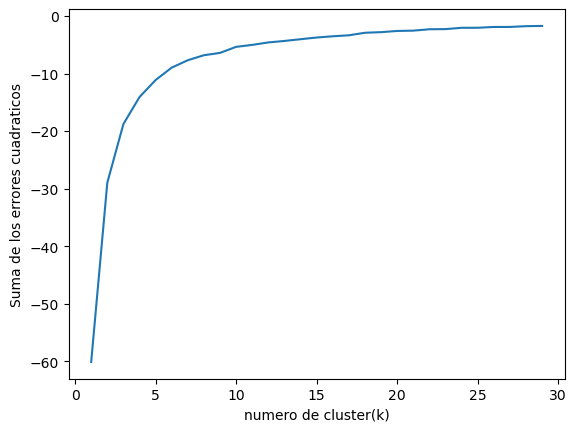

In [12]:
#Segmentacion de Cluster WCSS
nc=range(1,30)
kmeans=[KMeans(n_clusters=i) for i in nc]
score=[kmeans[i].fit(df_escalado).score(df_escalado)for i in range(len(kmeans))]

#Grafica de codo para determinar el numero de clusters
plt.xlabel('numero de cluster(k)')
plt.ylabel('Suma de los errores cuadraticos')
plt.plot(nc,score)
plt.show()

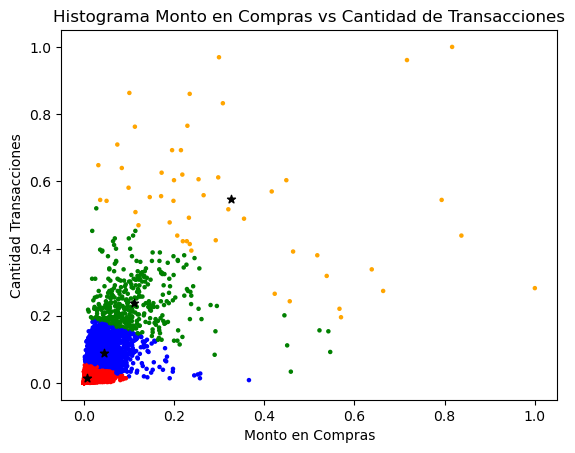

In [13]:
#Generar el modelo a partir de clusters o grupos
kmeans = KMeans(n_clusters=4).fit(df_escalado)
centroids=kmeans.cluster_centers_

labels=kmeans.predict(df_escalado)
df_escalado['label']=labels


#Graficamos los clusters
colores=['red','green','blue','orange']
asignar=[]
for row in labels:
    asignar.append(colores[row])

plt.scatter(df_escalado['ePURCHASES'],df_escalado['ePURCHASES_TRX'],c=asignar,s=5)
plt.scatter(centroids[:,0],centroids[:,1],marker='*',c='black')
plt.title('Histograma Monto en Compras vs Cantidad de Transacciones' )
plt.xlabel('Monto en Compras')
plt.ylabel('Cantidad Transacciones')
plt.show()

  label   color  size
0     0     red  6820
1     1   green   380
2     2    blue  1699
3     3  orange    51


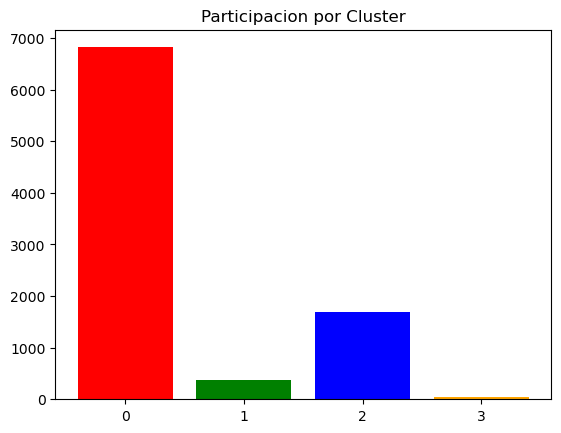

In [14]:
color = pd.DataFrame({'color':asignar})
dfAgrupado = pd.concat([df,df_escalado,color], axis = 1)
grupoColor=pd.DataFrame(dfAgrupado.groupby(['label','color'], as_index=False).size())

grupoColor['label']=grupoColor['label'].astype(str)
print(grupoColor)

fig, ax = plt.subplots()
ax.bar(grupoColor['label'], grupoColor['size'],color=grupoColor['color'])
plt.title('Participacion por Cluster')
plt.show() 

In [1]:
maxcluster = 0
df_maxCluster = df_escalado[df_escalado['label']==maxcluster]

maxMonto= df_maxCluster['ePURCHASES'].max()
minMonto = df_maxCluster['ePURCHASES'].min()
maxCantidad = df_maxCluster['ePURCHASES'].max()
minCantidad = df_maxCluster['ePURCHASES_TRX'].min()

print('Maximo monto en una compra',maxMonto)
print('Minimo monto en una compra',minMonto)
print('Maxima Cantidad Transacciones',maxCantidad)
print('Minima Cantidad Transacciones',minCantidad)

NameError: name 'df_escalado' is not defined

In [ ]:

df_filtered = dfAgrupado[ (dfAgrupado['ePURCHASES'] <= maxMonto) &
                  (dfAgrupado['ePURCHASES']>= minMonto) &
                  (dfAgrupado['ePURCHASES_TRX'] <= maxCantidad) &
                  (dfAgrupado['ePURCHASES_TRX'] >= minCantidad)]

print('Los clientes objetivos de la campaña son:')
print(df_filtered['CUST_ID'])
